# Hist init — composable workflow

Step-by-step initialization of tweezer grid locations and detection thresholds.

Each step is a separate cell so you can iterate cheaply: re-edit the grid without reloading 2000 images, re-fit thresholds with different `num_bins` instantly, etc.

**Workflow:**
1. Load scan context (metadata only).
2. Compute average image from a small subset.
3. Build mask, auto-detect spots (sanity check).
3.5. **Register CSV → image** (if a `*_coords.csv` exists in the scan dir): pick anchors, fit affine, project all sites. Falls back to the auto-detected spots if no CSV is present.
4. Interactive edit (with detected vs. CSV-inferred coloring).
5. Load images for threshold computation (cached in `images`).
6. Fit per-site double-Gaussian histograms → thresholds.
7. Inspect (grid overlay colored by infidelity, paginated histograms).
8. (optional) Second-pass edit — drop bad sites and re-fit.
9. Save calibration (opt-in to day-folder copy).

## 0. Setup

In [93]:
%matplotlib qt
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

from yb_analysis.detection import hist_init as hi

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configure

In [ ]:
scan_dir = r"D:\OneDrive - Harvard University\Documents - Yb\Data\20260518\data_20260518_134831"
num_tweezers = 400

# Mask parameters (Gaussian weighting for masked-intensity readout)
box_size = 9
sigma = 2.0

# Detection parameters
spot_sigma = 2.0    # LoG kernel size — expected spot radius in pixels
min_distance = 10   # minimum spacing between detected peaks

# Editor / registration parameters
snap_window = 8       # px radius around a click to snap to nearest LoG peak
delete_radius = 12    # max distance (px) from a right-click to count as delete
min_anchors = 3       # affine fit needs at least 3 non-collinear correspondences
match_tolerance = 5   # px — projected CSV pos within this of a detected spot counts as 'detected'

# How many images to load
n_avg = 200         # for the average image (fast spot detection)
n_thresh = 2000     # for the threshold histograms

# Histogram fit
num_bins = 50

## 2. Load context + average image

In [95]:
ctx = hi.load_scan_context(scan_dir)
print(f"num_seq={ctx['num_seq']}, num_images_per_seq={ctx['num_images']}, total_frames={ctx['total_frames']}")

avg_image = hi.compute_avg_image(ctx, n_avg=n_avg)
print(f'avg_image shape: {avg_image.shape}')

fig, ax = plt.subplots(figsize=(10, 7))
vmin, vmax = np.percentile(avg_image, [1, 99.5])
ax.imshow(avg_image, cmap='gray', vmin=vmin, vmax=vmax)
ax.set_title(f'Average of {min(ctx["num_seq"], n_avg)} images')
plt.show()

2026-05-18 13:55:15,176 INFO Averaging 200 of 222 sequence-first images


num_seq=222, num_images_per_seq=1, total_frames=222
avg_image shape: (1992, 2100)


## 3. Build mask + auto-detect spots

This is a sanity check — it shows what the LoG detector finds without any geometric prior. The output `spots` is also used as a fallback in the next cell when no CSV is present.

In [112]:
mask_mat = hi.make_mask(box_size=box_size, sigma=sigma)

spots = hi.detect_grid(avg_image, num_tweezers,
                       spot_sigma=spot_sigma,
                       min_distance=min_distance,
                       sort=False)
print(f'Auto-detected {len(spots)} / {num_tweezers} spots')

hi.plot_grid_overlay(avg_image, spots)
plt.show()

Auto-detected 468 / 468 spots


In [113]:
spots, rot = hi.sort_grid_rotated(spots, return_rotation=True)
print(f'Auto-detected {len(spots)} / {num_tweezers} spots (lattice rotation {rot:+.2f}°)')


TypeError: sort_grid_rotated() got an unexpected keyword argument 'return_rotation'

## 3.5. Register CSV → image (or fall back to auto-detect)

If a `*_coords.csv` file exists in `scan_dir`, this opens a side-by-side picker:
- **Left**: averaged atom image with **cyan rings** showing every auto-detected spot from cell 3 — click any of them.
- **Right**: scatter of CSV positions in µm with index labels — click the matching index.

Image clicks **snap to the nearest detected spot** within `match_tolerance` px (more precise than free-clicking). Repeat ≥ `min_anchors` times, press **Done**.

The affine transform is fit, all CSV points are projected into image pixels. Each CSV site is then matched to the nearest detected spot:
- **lime** = CSV site matched to a detected atom-image spot
- **orange** = CSV site with no matching atom-image spot (geometrically inferred only)
- **cyan** = "ghost" trap — a detected atom-image spot that's NOT in the CSV (loaded with atoms but unintended). Set `include_ghosts=False` to discard them at this stage; otherwise they're kept and you can right-click to delete in the editor.

If no CSV is found, the cell prints a notice and uses the auto-detected `spots` from the previous cell as the initial grid.

In [115]:
reg = hi.register_csv_grid(avg_image, scan_dir,
                           detected_spots=spots,
                           include_ghosts=True,
                           spot_sigma=spot_sigma,
                           snap_window=snap_window,
                           match_tolerance=match_tolerance,
                           min_anchors=min_anchors)

if reg is None:
    print('No coords CSV found — falling back to auto-detect grid.')
    initial_grid = spots
    is_detected = None
    is_csv = None
else:
    csv_mask = reg['is_csv']
    n_csv_det = int((csv_mask & reg['is_detected']).sum())
    n_csv_inf = int((csv_mask & ~reg['is_detected']).sum())
    n_ghosts = int((~csv_mask).sum())
    print(f"CSV: {os.path.basename(reg['csv_path'])} | "
          f"csv-detected {n_csv_det} | csv-inferred {n_csv_inf} | "
          f"ghosts {n_ghosts} | total grid {len(reg['grid'])} | "
          f"max anchor residual {reg['residuals_px'].max():.2f} px")
    initial_grid = reg['grid']
    is_detected = reg['is_detected']
    is_csv = reg['is_csv']
    hi.plot_grid_overlay(avg_image, initial_grid, box_size=box_size)
    plt.show()

2026-05-18 14:13:20,693 INFO No CSV matching *coords.csv in D:\OneDrive - Harvard University\Documents - Yb\Data\20260518\data_20260518_134831 — skipping registration.


No coords CSV found — falling back to auto-detect grid.


## 4. Interactive edit

**Mouse**: left-click adds a new site. **Right-click toggles** the nearest site between alive/dead — a "deleted" site is kept as a tombstone (dim gray, dashed) so its CSV index is preserved through to the histograms.  
**Keyboard** (cursor over image): `d` mark nearest alive site dead · `u` undo · `Enter` finish.  
**Buttons**: Done · Reset · Snap toggle · Contrast slider.

Site colors:
- **lime** = CSV site, matched to a real atom-image spot
- **orange** = CSV site, no matching spot (geometrically inferred)
- **cyan** = ghost trap (detected, not in CSV) — keep or right-click to mark dead
- **dim gray, dashed** = deleted (tombstoned) — its CSV index slot still appears in step 8 as "DELETED"
- **red** = newly added by left-click

Labels show CSV index for CSV sites and `+row` for non-CSV (ghosts/added).

In [116]:
edit_result = hi.edit_grid(avg_image, initial_grid,
                           spot_sigma=spot_sigma,
                           snap=True,
                           snap_window=snap_window,
                           delete_radius=delete_radius,
                           is_detected=is_detected,
                           is_csv=is_csv,
                           csv_indices=(reg['csv_indices'] if reg is not None else None),
                           box_size=box_size,
                           sort=False)   # preserve CSV order; tombstone dead

grid         = edit_result['grid']
csv_indices  = edit_result['csv_indices']
is_alive     = edit_result['is_alive']
is_csv_post  = edit_result['is_csv']
is_detected_post = edit_result['is_detected']

print(f"After edit: {len(grid)} rows ({int(is_alive.sum())} alive, "
      f"{int((~is_alive).sum())} deleted, "
      f"{int(is_csv_post.sum())} CSV, {int((~is_csv_post).sum())} non-CSV)")

After edit: 481 rows (457 alive, 24 deleted, 0 CSV, 481 non-CSV)


In [73]:
# Sort to bottom-left → up → right, including any clicks added in the editor.
# Reorders every parallel array so identity is preserved.
_, info = hi.sort_grid_rotated(grid, return_info=True, verbose=True)
order = info['order']
grid             = grid[order]
csv_indices      = csv_indices[order]
is_alive         = is_alive[order]
is_csv_post      = is_csv_post[order]
is_detected_post = is_detected_post[order]
print(f"Sorted: rotation={info['rotation_deg']:+.2f}°, spacing={info['spacing']:.1f}px, "
      f"columns={info['n_columns']}")


2026-05-13 18:49:32,671 INFO sort_grid_rotated: rotation=+3.46°, spacing=55.15 px, columns=34 (sizes min/median/max = 1/33/35)


Sorted: rotation=+3.46°, spacing=55.1px, columns=34


## 5. Load images for threshold computation

This is the slow step. The `images` array is reused by every subsequent re-fit, so you only pay it once.

In [117]:
images = hi.load_threshold_images(ctx, n_thresh=n_thresh)
print(f'images shape: {images.shape}')

2026-05-18 14:15:39,445 INFO Loading 222 images for threshold computation


images shape: (222, 1992, 2100)


## 6. Fit per-site thresholds

Re-run this cell after tweaking `num_bins`, the mask, or the grid — the slow image load above is cached.

In [118]:
hist_data, thresholds, gauss_fits, infidelities = hi.compute_thresholds(
    images, grid, mask_mat, num_bins=num_bins, is_alive=is_alive
)
print(f'Mean infidelity:   {np.nanmean(infidelities):.4e}')
print(f'Median infidelity: {np.nanmedian(infidelities):.4e}')

n_show = min(10, int(np.isfinite(infidelities).sum()))
finite_idx = np.where(np.isfinite(infidelities))[0]
worst = finite_idx[np.argsort(infidelities[finite_idx])[-n_show:][::-1]]
print(f'Worst {n_show} sites:')
for rank, i in enumerate(worst, 1):
    label = (f'CSV index {csv_indices[i]}' if csv_indices[i] > 0
             else f'row {i + 1} (non-CSV)')
    print(f'  {rank:>2}. {label:<22}  infidelity = {infidelities[i]:.4e}')

Mean infidelity:   6.1870e-02
Median infidelity: 5.1810e-02
Worst 10 sites:
   1. row 454 (non-CSV)       infidelity = 5.4205e-01
   2. row 481 (non-CSV)       infidelity = 3.7542e-01
   3. row 331 (non-CSV)       infidelity = 2.4919e-01
   4. row 473 (non-CSV)       infidelity = 2.2962e-01
   5. row 475 (non-CSV)       infidelity = 2.2667e-01
   6. row 175 (non-CSV)       infidelity = 2.2050e-01
   7. row 472 (non-CSV)       infidelity = 2.0941e-01
   8. row 474 (non-CSV)       infidelity = 2.0758e-01
   9. row 427 (non-CSV)       infidelity = 1.9905e-01
  10. row 413 (non-CSV)       infidelity = 1.9819e-01


## 7. Inspect — grid overlay colored by infidelity

In [122]:
hi.plot_grid_overlay(avg_image, grid[is_alive],
                     infidelities=infidelities[is_alive],
                     labels=csv_indices[is_alive],   # preserve CSV identity
                     box_size=box_size)
plt.show()

## 8. Inspect — paginated per-site histograms

Single figure with **Prev / Next** buttons (or **Left / Right arrow** keys, **Home / End** to jump). Pass `sort_by='infidelity'` to view sites worst-first — useful when you have thousands of tweezers.

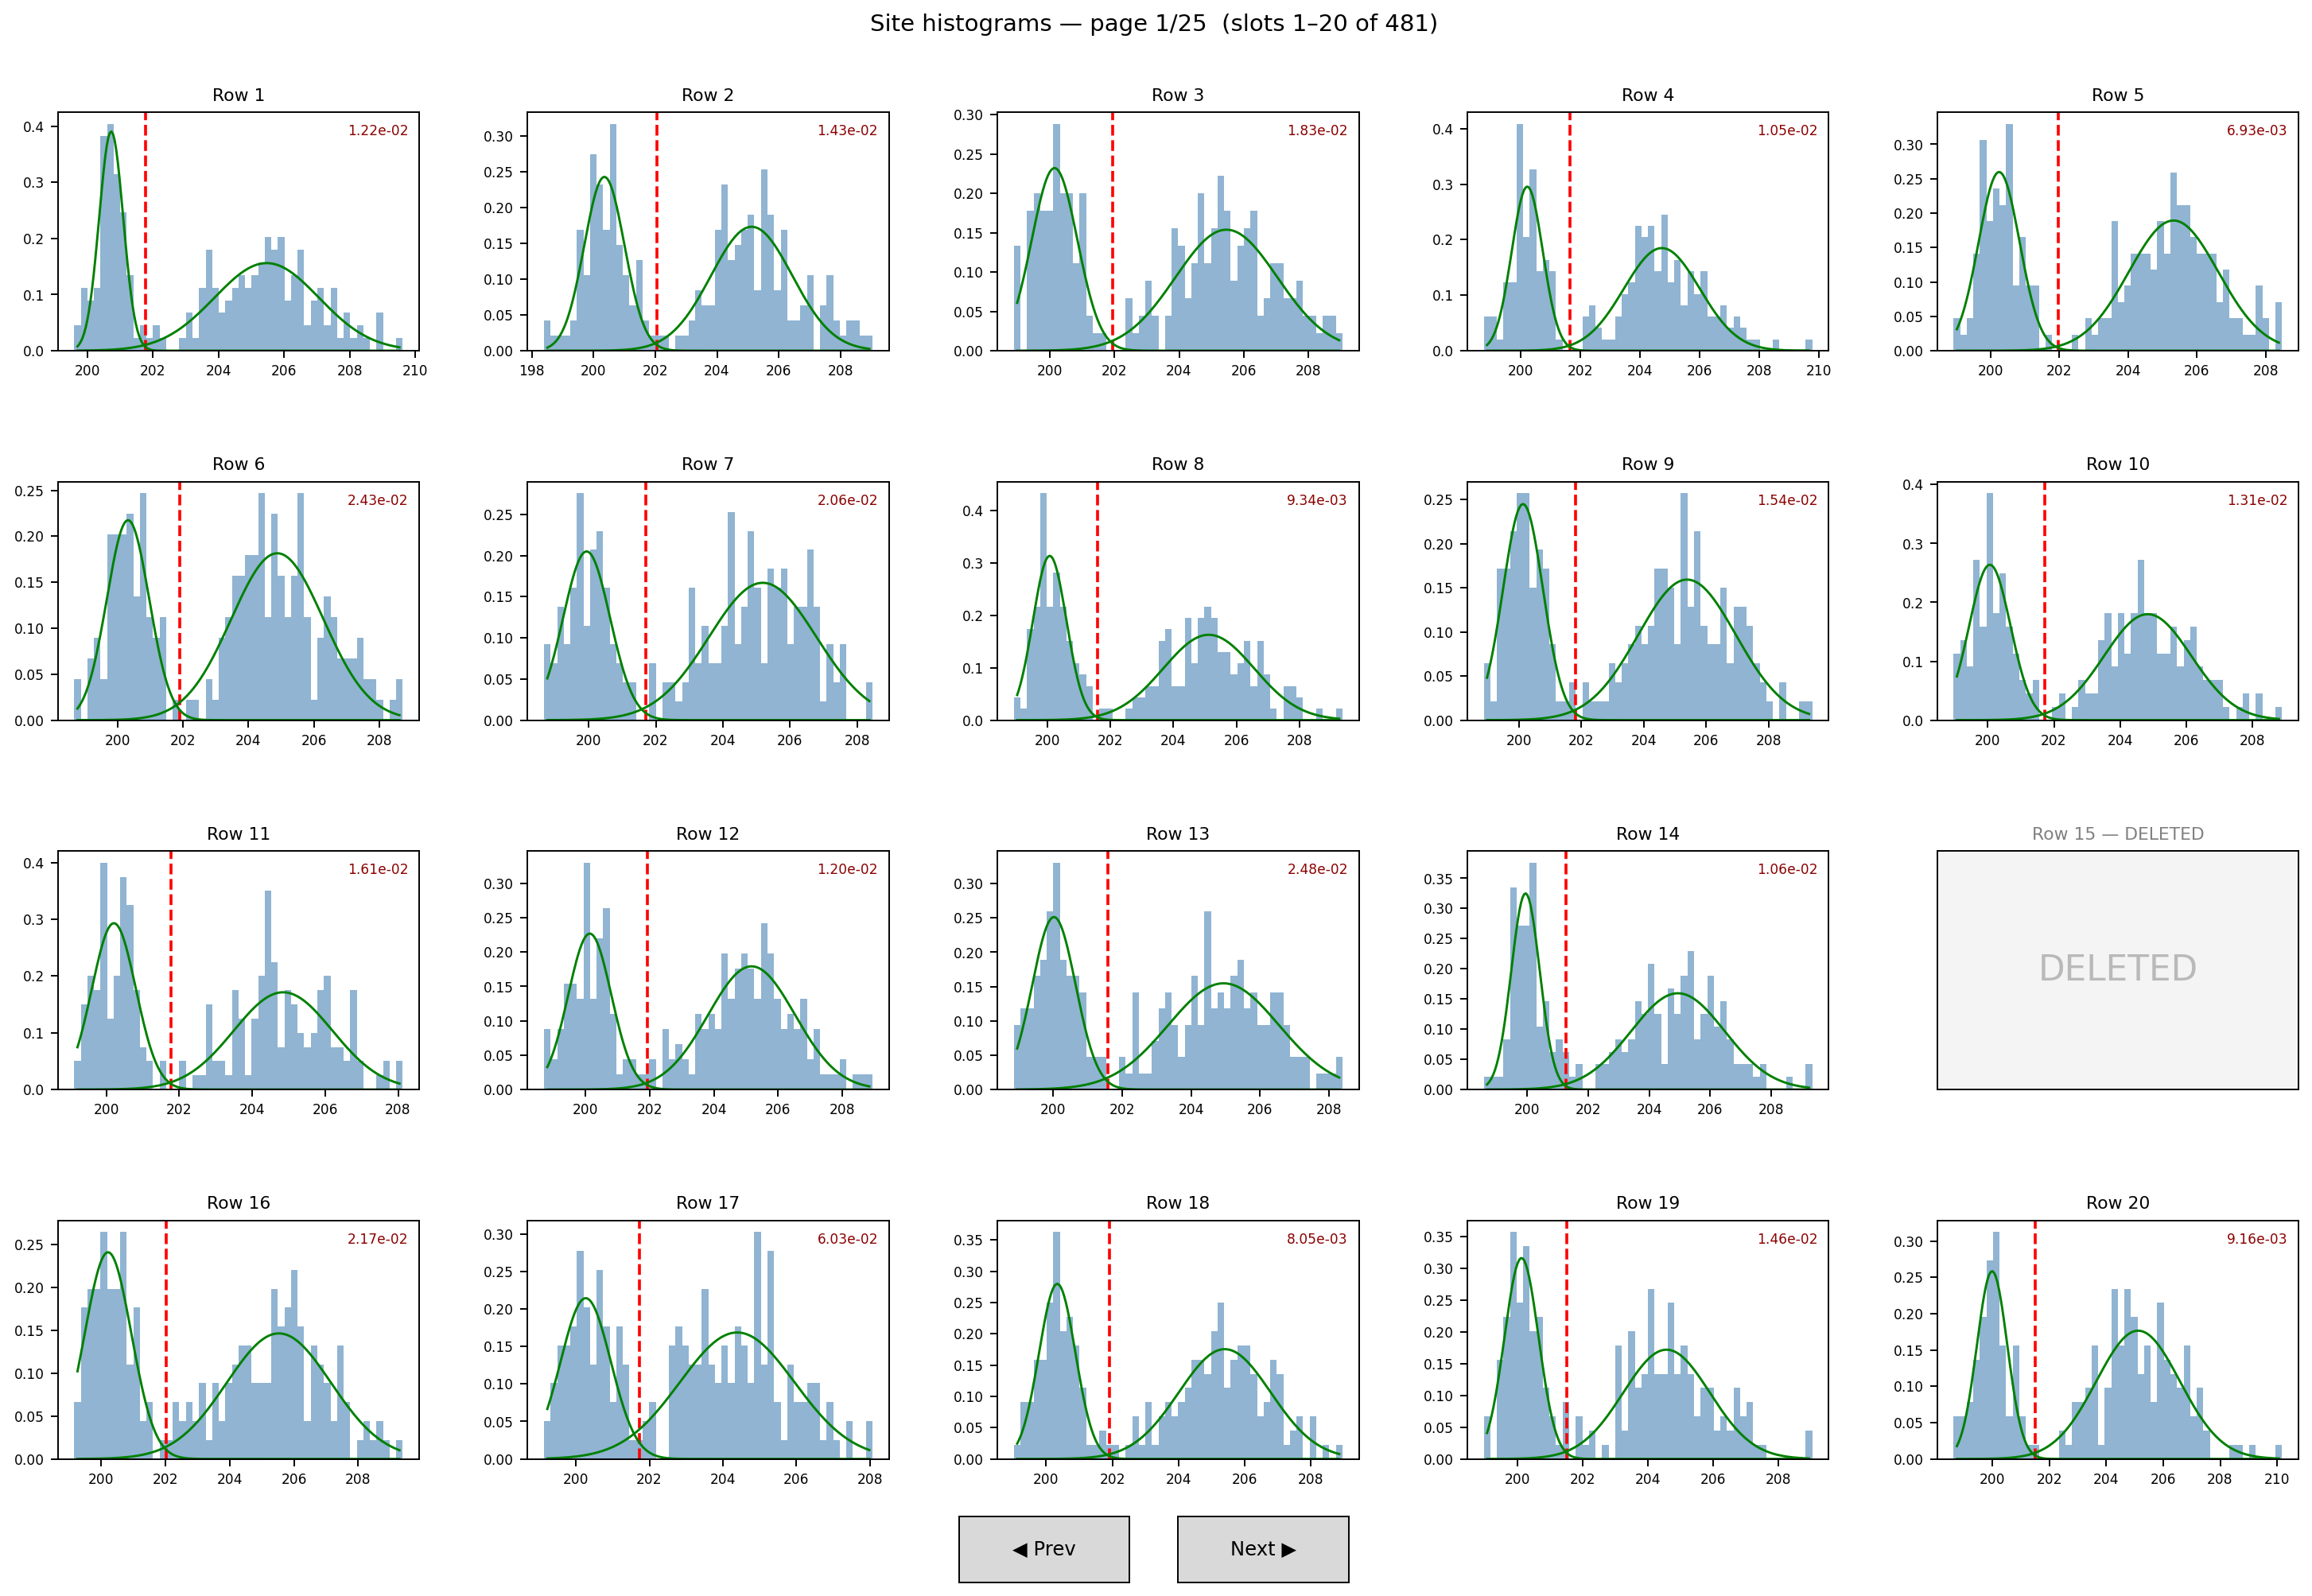

In [120]:
hi.plot_histograms(hist_data, thresholds, gauss_fits, infidelities,
                   csv_indices=csv_indices,
                   is_alive=is_alive,
                   sort_by=None)   # set 'infidelity' to scan worst sites first

## 9. (optional) Second-pass edit — drop bad sites in-place

Opens the editor with sites colored by their infidelity (green = good, red = bad). Right-click red sites to drop them, then re-run cell 6 to refit thresholds on the trimmed grid.

Skip this cell if you're happy with the first pass.

In [123]:
edit_result = hi.edit_grid(avg_image, grid,
                           spot_sigma=spot_sigma,
                           snap=True,
                           snap_window=snap_window,
                           delete_radius=delete_radius,
                           infidelities=infidelities,
                           csv_indices=csv_indices,
                           is_alive=is_alive,
                           box_size=box_size,
                           sort=False)
grid        = edit_result['grid']
csv_indices = edit_result['csv_indices']
is_alive    = edit_result['is_alive']
print(f'After second-pass edit: {int(is_alive.sum())} alive / {int((~is_alive).sum())} deleted — re-run cell 6 to refit.')

After second-pass edit: 456 alive / 25 deleted — re-run cell 6 to refit.


## 10. Save calibration

Writes `gridLocations.txt`, `threshold.mat`, `histData.mat` into `scan_dir`. Tombstoned (deleted) sites are dropped before writing.

`gridLocations.txt` is written with **three columns** when `csv_indices` is supplied: `Y\tX\tSite_Index`. The Site_Index column carries the CSV index for CSV-derived rows and `-1` for ghosts / user-clicked rows. Deleted CSV indices simply don't appear in the file — the gap in the Site_Index sequence makes the omission obvious.

Set `save_to_day_folder=True` only when this scan is the *day's* reference calibration — it overwrites the day-level files.

In [124]:
hi.save_calibration(scan_dir, grid, thresholds, infidelities,
                    gauss_fits, hist_data,
                    is_alive=is_alive,         # drop tombstones from saved files
                    csv_indices=csv_indices,   # write Site_Index column (CSV idx; -1 for non-CSV)
                    save_to_day_folder=False)

2026-05-18 14:26:09,277 INFO save_calibration: dropping 25 dead site(s)
2026-05-18 14:26:09,278 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260518\data_20260518_134831\gridLocations.txt
2026-05-18 14:26:09,291 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260518\data_20260518_134831\threshold.mat
2026-05-18 14:26:09,306 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260518\data_20260518_134831\histData.mat


## (Optional) Bundle results

In [ ]:
result = {
    'grid_locations': grid,
    'thresholds': thresholds,
    'infidelities': infidelities,
    'gauss_fits': gauss_fits,
    'hist_data': hist_data,
    'mask_mat': mask_mat,
    'avg_image': avg_image,
    'scan_dir': scan_dir,
    'ctx': ctx,
    'registration': reg,
}
print({k: (v.shape if hasattr(v, 'shape') else type(v).__name__) for k, v in result.items()})